# **you need to do that**

Find the Shared Folder: Go to your Google Drive and click on the "Shared with me" tab on the left.

Create the Shortcut: Right-click the DEPIProject folder (the one the leader shared) and select Organize > Add shortcut.

Place it in "My Drive": Choose "My Drive" as the location

In [ ]:
from google.colab import drive
import os

# 1. This will ask EACH person to "Allow" access to THEIR own drive.
# This is safe! It just lets the code see the shortcut they just made.
drive.mount('/content/drive')

# 2. Because everyone has the shortcut in 'MyDrive', this path works for all 3 people!
BASE_PATH = '/content/drive/MyDrive/DEPIProject'
DATA_PATH = os.path.join(BASE_PATH, 'EuroSAT')

# 3. Quick check to prove it works
if os.path.exists(DATA_PATH):
    print(f"✅ Success! You are connected to the shared project.")
    print(f"I can see {len(os.listdir(DATA_PATH))} categories.")
else:
    print("❌ Still not working. Make sure your shortcut is named 'DEPIProject' exactly.")

Mounted at /content/drive
✅ Success! You are connected to the shared project.
I can see 10 categories.


## Speeding up Multispectral Data Access (Local Copy)

To accelerate operations on the multispectral data, we'll copy the `EuroSAT_MS` dataset from Google Drive to the Colab local runtime. This provides much faster I/O compared to reading directly from Drive.


In [ ]:
import shutil
import os

# Define the local path for the multispectral data
LOCAL_MS_DATA_PATH = '/content/EuroSAT_MS_Local'

# Source path on Google Drive
SOURCE_MS_PATH = os.path.join(BASE_PATH, 'EuroSAT_MS')

print(f"🚀 Moving multispectral data from Drive ({SOURCE_MS_PATH}) to local storage ({LOCAL_MS_DATA_PATH})...")

# Remove existing local directory if it exists to ensure a clean copy
if os.path.exists(LOCAL_MS_DATA_PATH):
    shutil.rmtree(LOCAL_MS_DATA_PATH)

# Copy the entire directory using the custom function with a progress bar
copy_directory_with_progress(SOURCE_MS_PATH, LOCAL_MS_DATA_PATH)

print("✅ Done! Multispectral data is now local.")

# Update MS_DATA_PATH to point to the local copy
MS_DATA_PATH = LOCAL_MS_DATA_PATH

print(f"MS_DATA_PATH updated to: {MS_DATA_PATH}")

🚀 Moving multispectral data from Drive (/content/drive/MyDrive/DEPIProject/EuroSAT_MS) to local storage (/content/EuroSAT_MS_Local)...


Copying EuroSAT_MS:   0%|          | 0/27000 [00:00<?, ?file/s]

✅ Done! Multispectral data is now local.
MS_DATA_PATH updated to: /content/EuroSAT_MS_Local


In [ ]:
import shutil

# Define the local path for the multispectral data
LOCAL_MS_DATA_PATH = '/content/EuroSAT_MS_Local'

# Source path on Google Drive
SOURCE_MS_PATH = os.path.join(BASE_PATH, 'EuroSAT_MS')

print(f"🚀 Moving multispectral data from Drive ({SOURCE_MS_PATH}) to local storage ({LOCAL_MS_DATA_PATH})...")

# Remove existing local directory if it exists to ensure a clean copy
if os.path.exists(LOCAL_MS_DATA_PATH):
    shutil.rmtree(LOCAL_MS_DATA_PATH)

# Copy the entire directory
shutil.copytree(SOURCE_MS_PATH, LOCAL_MS_DATA_PATH)

print("✅ Done! Multispectral data is now local.")

# Update MS_DATA_PATH to point to the local copy
MS_DATA_PATH = LOCAL_MS_DATA_PATH

print(f"MS_DATA_PATH updated to: {MS_DATA_PATH}")

🚀 Moving multispectral data from Drive (/content/drive/MyDrive/DEPIProject/EuroSAT_MS) to local storage (/content/EuroSAT_MS_Local)...
✅ Done! Multispectral data is now local.
MS_DATA_PATH updated to: /content/EuroSAT_MS_Local


#**Land Use and Land Cover Classification Project**

###**Overview:**
###This project focuses on classifying land use and land cover (LULC) using multispectral satellite imagery from the Sentinel-2 mission. By leveraging Deep Neural Networks (DNNs), the system aims to accurately identify various land types, including urban areas, agricultural land, water bodies, desert, roads, and vegetation.
###**Problem Statement:**
###Satellite imagery has become an indispensable tool in 2026 for addressing environmental challenges, acting as a "bird's-eye view" that enables precise monitoring of the Earth's surface, tracking of climate change, and management of natural resources. By categorizing land cover and land use, this technology supports sustainable development, aids in reducing waste, and helps identify areas of environmental degradation, such as deforestation or urban sprawl.
###However, the sheer volume of data produced-often requiring complex analysis-presents significant challenges in interpretation and processing, necessitating advanced AI and machine learning techniques.


##**(1) Data Description and Preparation:**
###The EuroSAT dataset contains 27,000 labelled 64x64 pixel Sentinel-2 satellite image patches with 10 different LULC categories. Both RGB and multi-spectral (MS) TIFs.




###Library Imports

In [ ]:
#Standard
import os
import glob
import random
import shutil
import subprocess
import warnings

#Numerical
import numpy as np
import pandas as pd

#Visualisation
import cv2
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns

#Geospatial
import rasterio
from osgeo import gdal, ogr, osr
import geopandas as gpd
from shapely.geometry import Point, Polygon

#Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, cohen_kappa_score
)

#PyTorch
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, models, transforms
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch version : {torch.__version__}')
print(f'Torchvision     : {torchvision.__version__}')

Device: cpu
PyTorch version : 2.10.0+cpu
Torchvision     : 0.25.0+cpu


In [ ]:
from tqdm.notebook import tqdm

def copy_directory_with_progress(src, dst):
    """Copies a directory from src to dst with a progress bar."""
    # Create destination directory if it doesn't exist
    os.makedirs(dst, exist_ok=True)

    total_files = 0
    for root, dirs, files in os.walk(src):
        total_files += len(files)

    with tqdm(total=total_files, unit='file', desc=f'Copying {os.path.basename(src)}') as pbar:
        for root, dirs, files in os.walk(src):
            for d in dirs:
                os.makedirs(os.path.join(dst, os.path.relpath(os.path.join(root, d), src)), exist_ok=True)
            for f in files:
                src_path = os.path.join(root, f)
                dst_path = os.path.join(dst, os.path.relpath(src_path, src))
                shutil.copy2(src_path, dst_path)
                pbar.update(1)


###(A) Loading RGB Dataset

In [ ]:
rgb_base_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

rgb_dataset  = datasets.ImageFolder(DATA_PATH, transform=rgb_base_transform)
class_names  = rgb_dataset.classes
dataset_size = len(rgb_dataset)

print(f'RGB dataset loaded — {dataset_size:,} images, {len(class_names)} classes')
print(f'Classes: {class_names}')
sample_tensor, sample_label = rgb_dataset[0]
print(f'\nSample tensor shape : {sample_tensor.shape}  (C, H, W)')
print(f'Sample class        : {class_names[sample_label]}')


RGB dataset loaded — 27,000 images, 10 classes
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Sample tensor shape : torch.Size([3, 64, 64])  (C, H, W)
Sample class        : AnnualCrop


### (B) Splitting RGB Dataset into Train, Validation, and Test Sets

In [ ]:
all_indices = list(range(dataset_size))
all_labels  = [rgb_dataset.targets[i] for i in all_indices]

# 80 % train / 10 % val / 10 % test
train_idx, temp_idx, _, temp_labels = train_test_split(
    all_indices, all_labels,
    test_size=0.20, stratify=all_labels, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=SEED
)

train_data = Subset(rgb_dataset, train_idx)
val_data   = Subset(rgb_dataset, val_idx)
test_data  = Subset(rgb_dataset, test_idx)

print(f'Train : {len(train_data):>6,} images ({len(train_data)/dataset_size*100:.0f}%)')
print(f'Val   : {len(val_data):>6,} images ({len(val_data)/dataset_size*100:.0f}%)')
print(f'Test  : {len(test_data):>6,} images ({len(test_data)/dataset_size*100:.0f}%)')

BATCH_SIZE  = 32
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('\nDataLoaders created for RGB train / val / test.')


Train : 21,600 images (80%)
Val   :  2,700 images (10%)
Test  :  2,700 images (10%)

DataLoaders created for RGB train / val / test.


### (C) Loading Multispectral Dataset (TIFF files)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Custom loader: reads all 13 Sentinel-2 bands from a GeoTIFF and returns a
# float32 tensor of shape (13, H, W).  This bypasses PIL entirely — necessary
# because PIL cannot open multi-band TIFF files correctly.
# ─────────────────────────────────────────────────────────────────────────────
def tif_loader(path: str) -> torch.Tensor:
    """Read a GeoTIFF and return a float32 tensor (C, H, W)."""
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)
    return torch.from_numpy(arr)


# ─────────────────────────────────────────────────────────────────────────────
# Transforms for tensors (NOT PIL images).
# torchvision v0.8+ supports tensor-based Resize / CenterCrop.
# Normalization per-band is applied AFTER computing actual statistics (§3C).
# ─────────────────────────────────────────────────────────────────────────────
ms_base_transform = transforms.Compose([
    transforms.Resize((64, 64),
                      antialias=True),
    transforms.CenterCrop(64),
    # Normalisation is added once per-band statistics are known (see §3C).
])

if not os.path.exists(MS_DATA_PATH):
    print(f' MS_DATA_PATH not found: {MS_DATA_PATH}')
    ms_dataset = None
    ms_class_names = []
else:
    ms_dataset = datasets.ImageFolder(
        MS_DATA_PATH,
        transform=ms_base_transform,
        loader=tif_loader
    )
    ms_class_names = ms_dataset.classes
    ms_dataset_size = len(ms_dataset)

    print(f'MS dataset loaded  — {ms_dataset_size:,} images, {len(ms_class_names)} classes')
    print(f'Classes: {ms_class_names}')

    sample_ms, sample_ms_label = ms_dataset[0]
    print(f'\nSample tensor shape : {sample_ms.shape}  (C=13 bands, H, W)')
    print(f'Sample class        : {ms_class_names[sample_ms_label]}')
    print(f'Value range         : [{sample_ms.min():.1f}, {sample_ms.max():.1f}]')

MS dataset loaded  — 27,000 images, 10 classes
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Sample tensor shape : torch.Size([13, 64, 64])  (C=13 bands, H, W)
Sample class        : AnnualCrop
Value range         : [9.0, 3490.0]


### (D) Splitting MS Dataset into Train, Validation, and Test Sets

In [ ]:
if ms_dataset is not None:
    ms_all_idx    = list(range(ms_dataset_size))
    ms_all_labels = ms_dataset.targets

    ms_train_idx, ms_temp_idx, _, ms_temp_labels = train_test_split(
        ms_all_idx, ms_all_labels,
        test_size=0.20, stratify=ms_all_labels, random_state=SEED
    )
    ms_val_idx, ms_test_idx = train_test_split(
        ms_temp_idx, test_size=0.50, stratify=ms_temp_labels, random_state=SEED
    )

    ms_train_data = Subset(ms_dataset, ms_train_idx)
    ms_val_data   = Subset(ms_dataset, ms_val_idx)
    ms_test_data  = Subset(ms_dataset, ms_test_idx)

    ms_train_loader = DataLoader(ms_train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    ms_val_loader   = DataLoader(ms_val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    ms_test_loader  = DataLoader(ms_test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f'MS Train : {len(ms_train_data):>6,}')
    print(f'MS Val   : {len(ms_val_data):>6,}')
    print(f'MS Test  : {len(ms_test_data):>6,}')

MS Train : 21,600
MS Val   :  2,700
MS Test  :  2,700


##**(2) Exploratory Data Analysis**(Visualizing the dataset characteristics before modeling):




###(A) Class distribution charts:

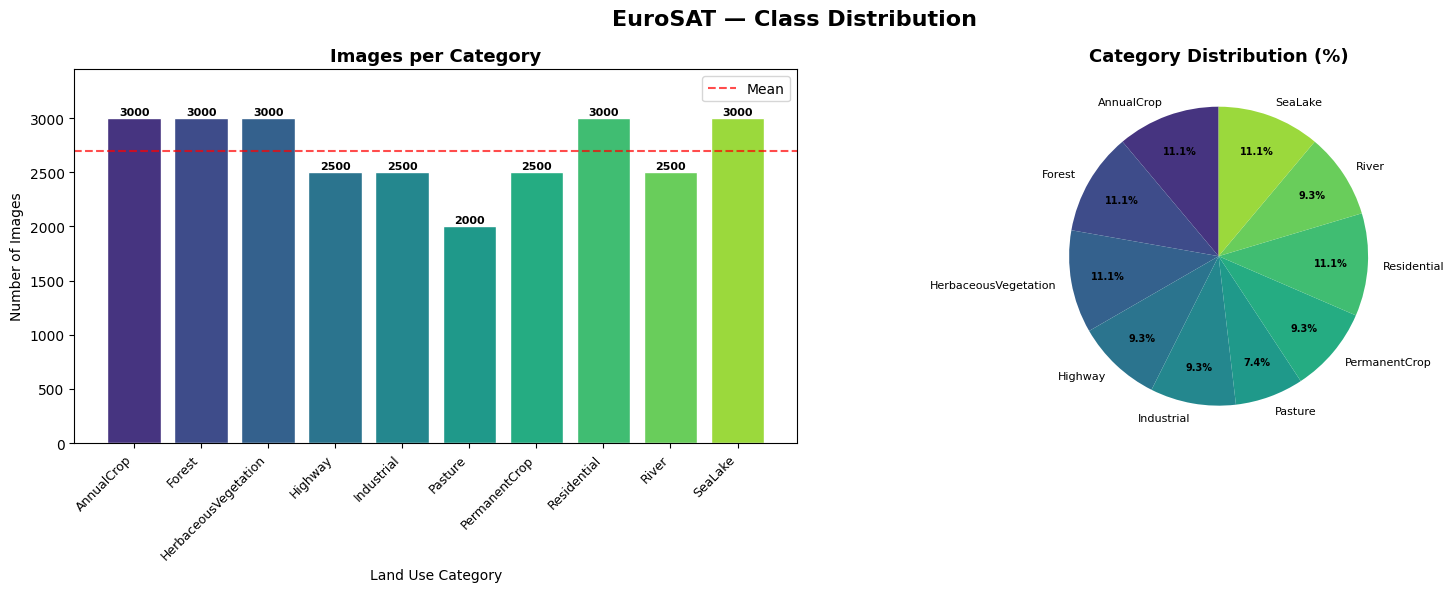

In [ ]:
CATEGORIES = class_names

dataset_counts = {cls: 0 for cls in class_names}
for _, lbl in rgb_dataset.samples:
    dataset_counts[class_names[lbl]] += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EuroSAT — Class Distribution', fontsize=16, fontweight='bold')

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(CATEGORIES)))
bars = axes[0].bar(CATEGORIES, dataset_counts.values(), color=colors, edgecolor='white')
axes[0].set_title('Images per Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Land Use Category')
axes[0].set_ylabel('Number of Images')
axes[0].set_xticklabels(CATEGORIES, rotation=45, ha='right', fontsize=9)
axes[0].axhline(np.mean(list(dataset_counts.values())), color='red',
                linestyle='--', alpha=0.7, label='Mean')
axes[0].legend()
for bar, val in zip(bars, dataset_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 str(val), ha='center', fontsize=8, fontweight='bold')
axes[0].set_ylim(0, max(dataset_counts.values()) * 1.15)

wedges, texts, autotexts = axes[1].pie(
    dataset_counts.values(), labels=CATEGORIES,
    autopct='%1.1f%%', colors=colors, startangle=90, pctdistance=0.75)
for t in texts:     t.set_fontsize(8)
for t in autotexts: t.set_fontsize(7); t.set_fontweight('bold')
axes[1].set_title('Category Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plots_dir = os.path.join(BASE_PATH, 'plots')
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, 'eda_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

###(B) Sample images from each category:

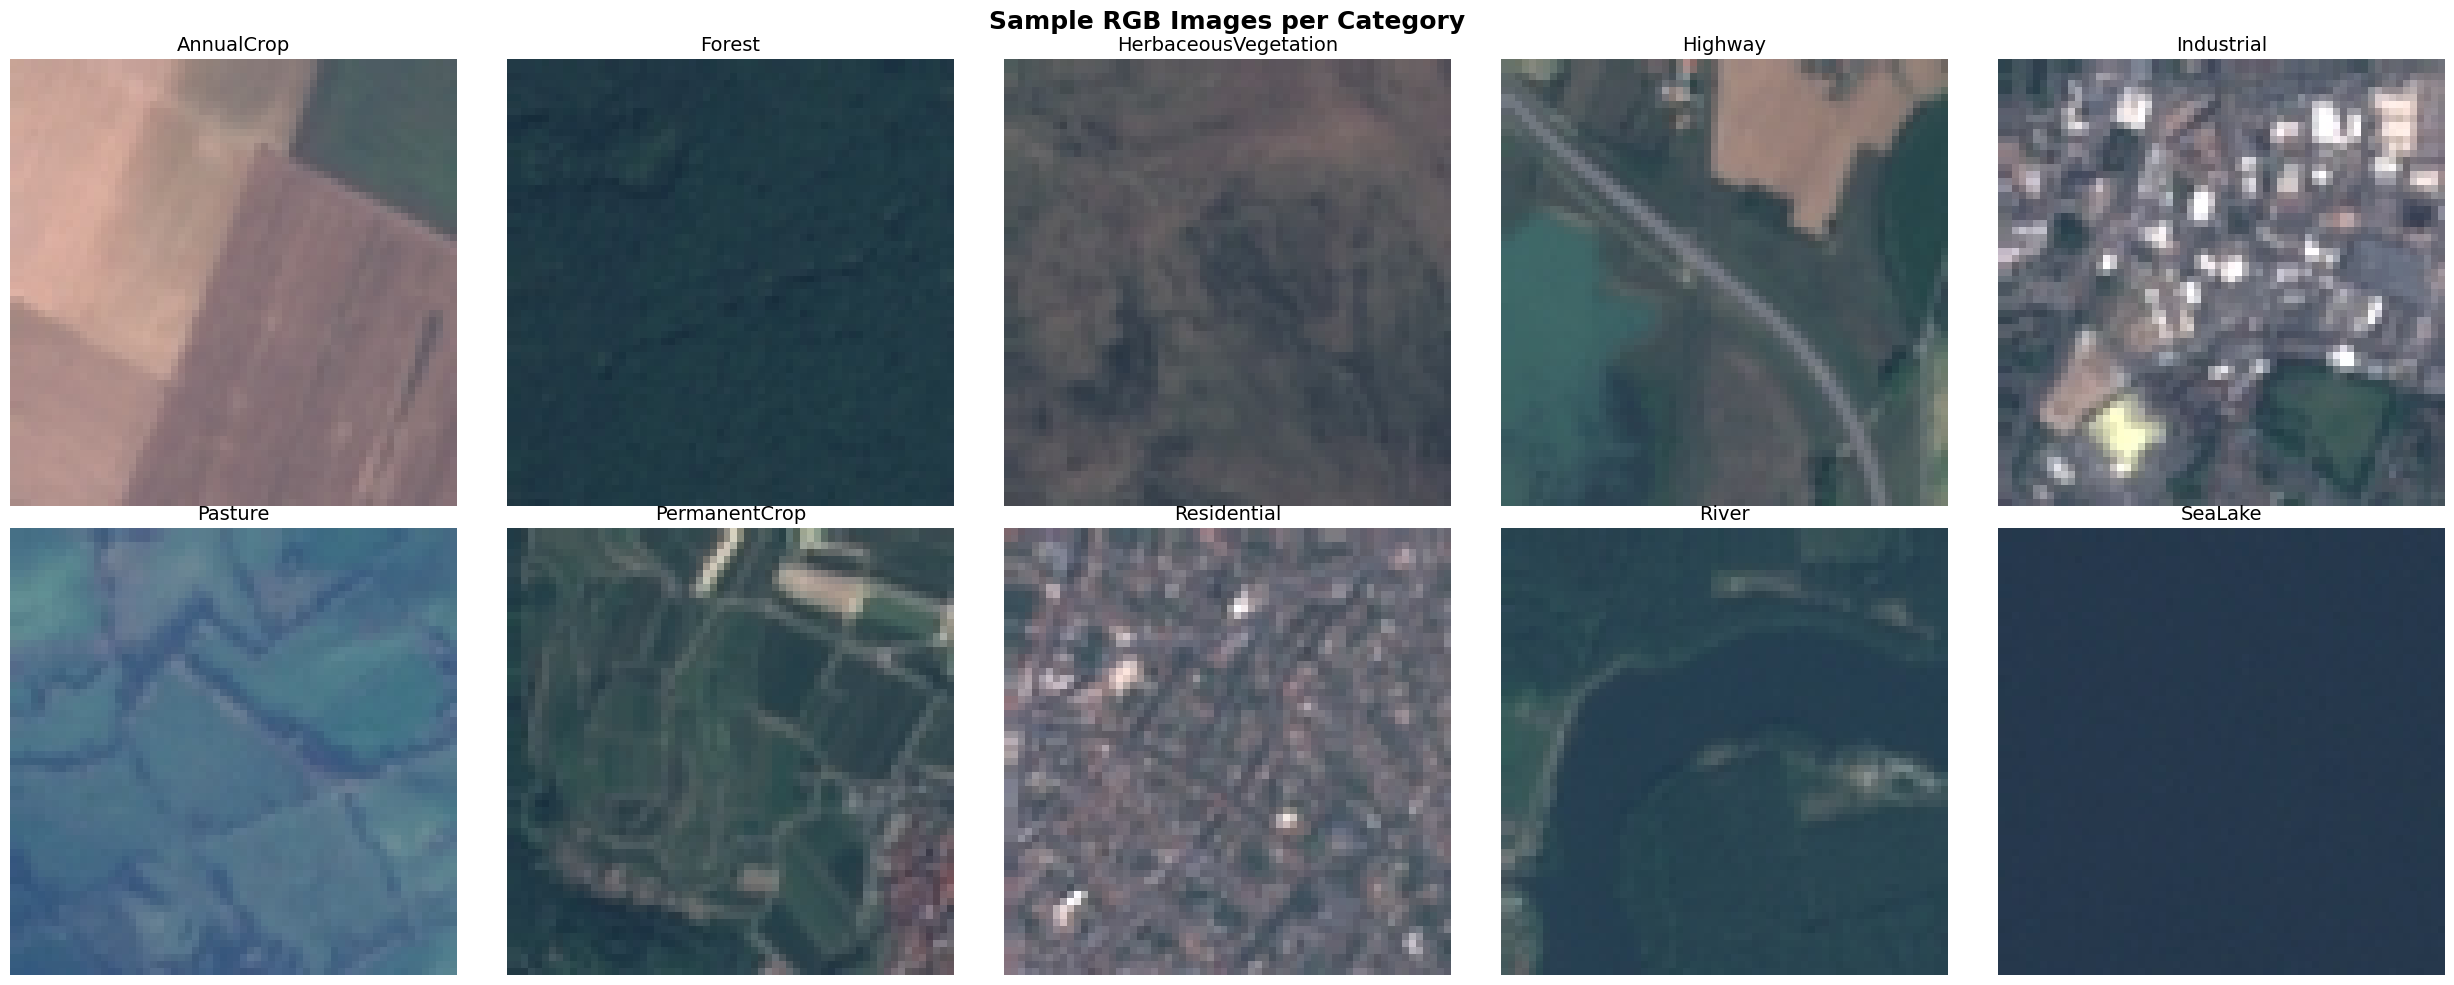

In [ ]:
# Group file paths by class
class_image_paths = {i: [] for i in range(len(class_names))}
for path, lbl in rgb_dataset.samples:
    class_image_paths[lbl].append(path)

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle('Sample RGB Images per Category', fontsize=18, fontweight='bold')

for i, cls_name in enumerate(class_names):
    row, col = divmod(i, 5)
    path = random.choice(class_image_paths[i])
    img  = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    axes[row, col].imshow(img)
    axes[row, col].set_title(cls_name, fontsize=14)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

###(C) Spectral Indices Visualisation per Category (TIFF):
### Displays **RGB composite, NDVI, NDWI, and NDBI** for one sample per class.

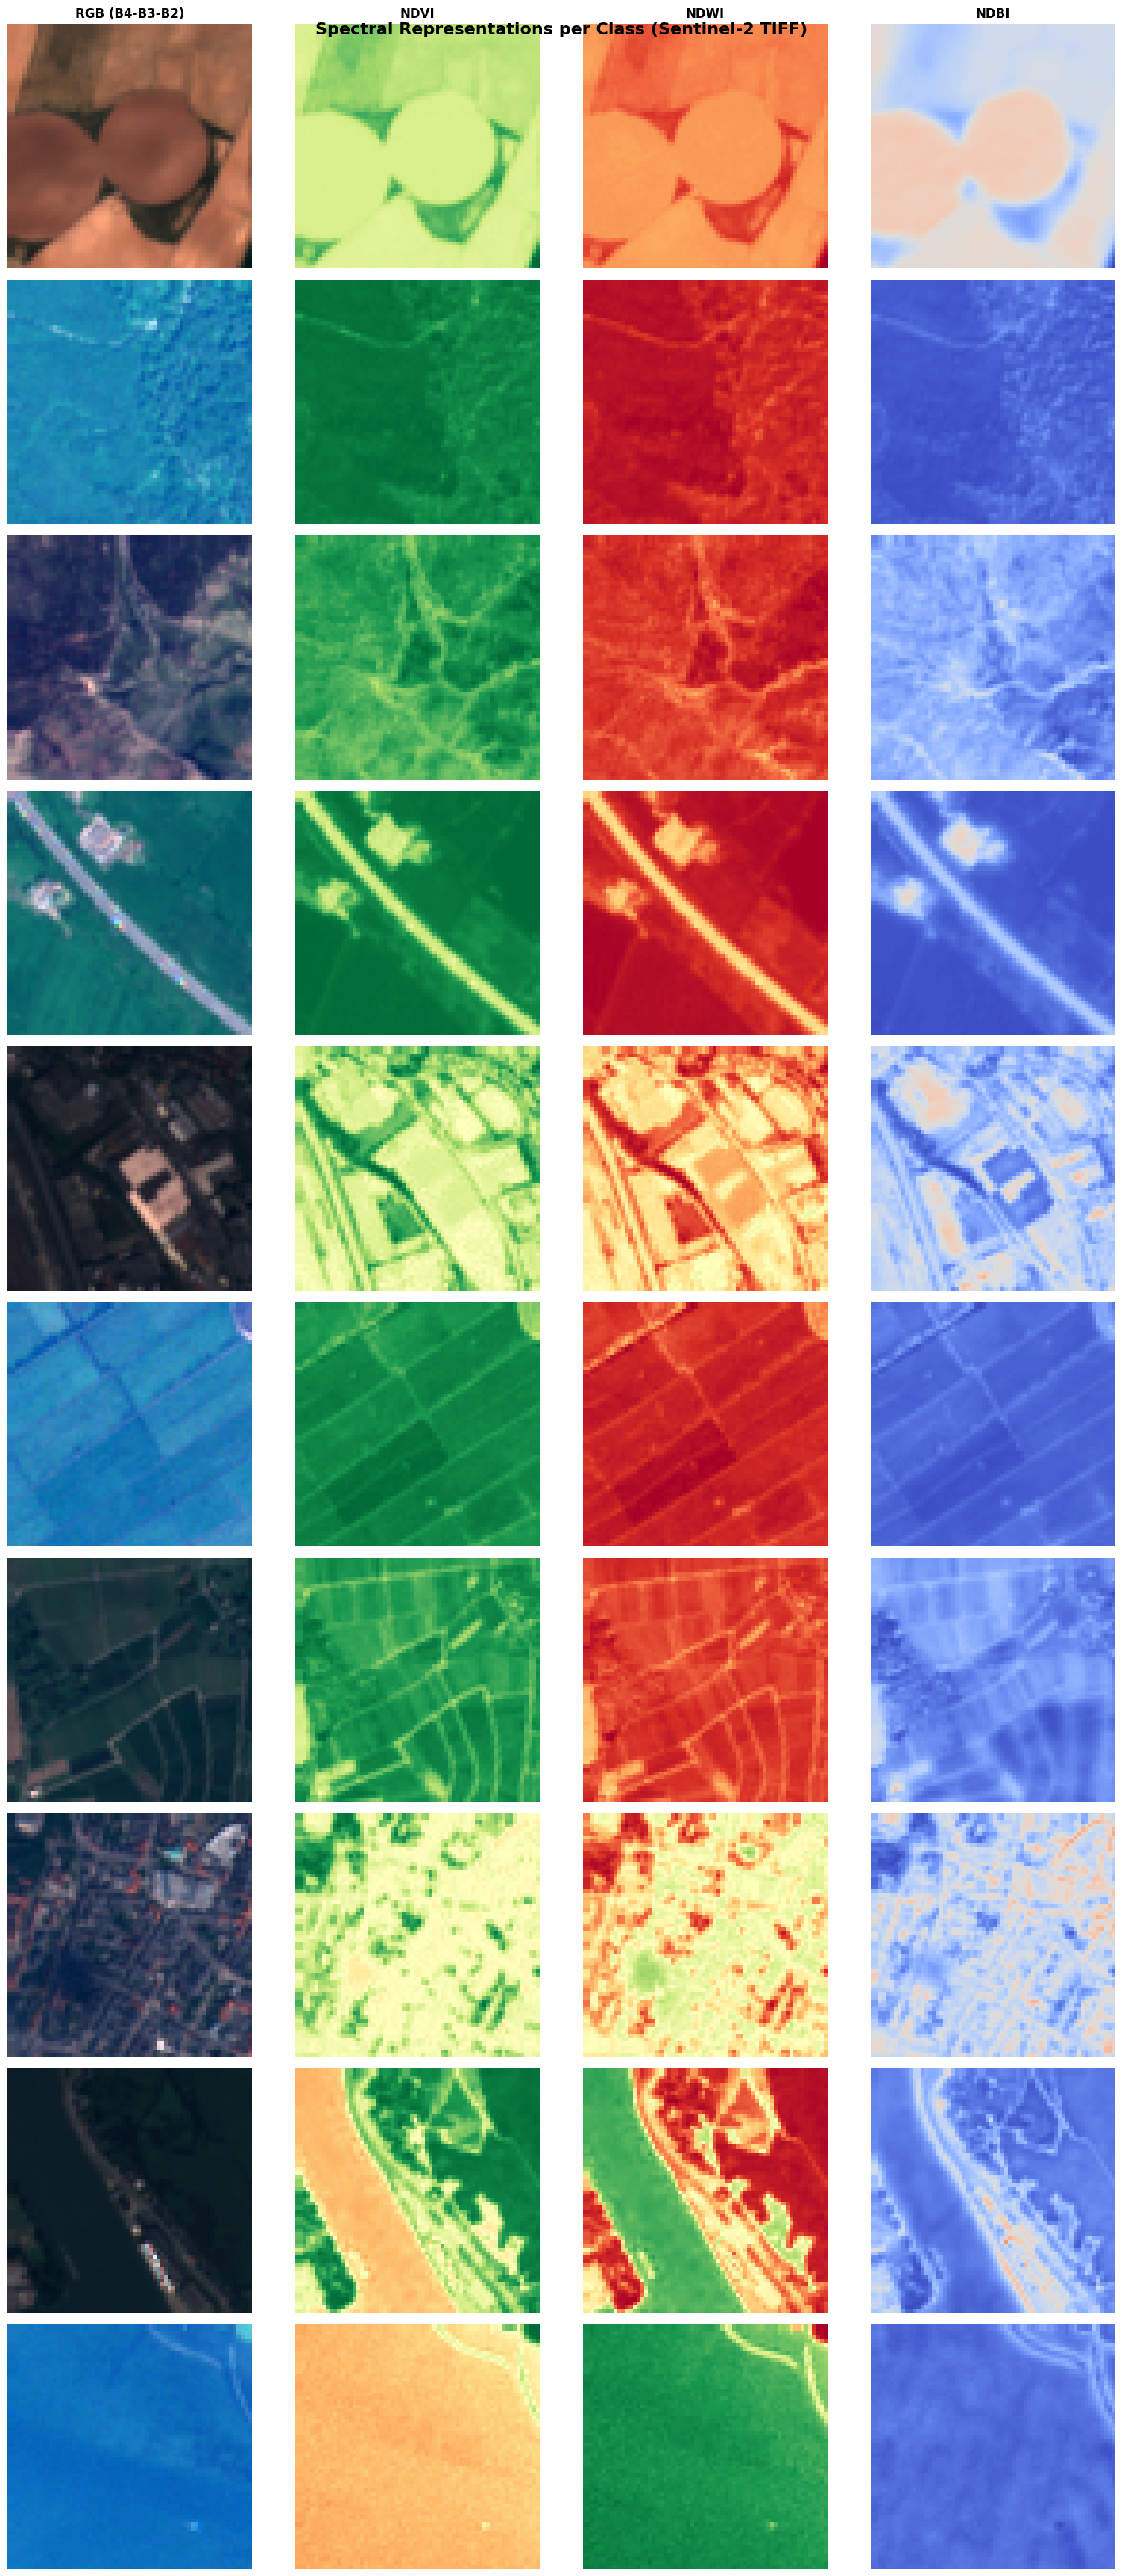

In [ ]:
# Sentinel-2 band index mapping (0-indexed from rasterio.read())
# B01=0  B02=1(Blue)  B03=2(Green)  B04=3(Red)  B05=4  B06=5  B07=6
# B08=7(NIR)  B8A=8  B09=9  B10=10  B11=11(SWIR1)  B12=12(SWIR2)

BAND_IDX = dict(BLUE=1, GREEN=2, RED=3, NIR=7, SWIR1=11)

def load_tif_bands(path):
    """Return a dict of named band arrays (float32, H×W)."""
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)  # (C, H, W)
    return {name: arr[idx] for name, idx in BAND_IDX.items()}

def norm01(x):
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo + 1e-6)

def spectral_index(a, b):
    """(a - b) / (a + b + eps) — safe for zero denominators."""
    return (a - b) / (a + b + 1e-6)

#Build sample-path lookup from the MS dataset
if ms_dataset is not None:
    ms_class_paths = {i: [] for i in range(len(ms_class_names))}
    for path, lbl in ms_dataset.samples:
        ms_class_paths[lbl].append(path)

    rep_titles  = ['RGB (B4-B3-B2)', 'NDVI', 'NDWI', 'NDBI']
    colormaps   = [None, 'RdYlGn', 'RdYlGn', 'coolwarm']
    n_cls, n_rep = len(ms_class_names), len(rep_titles)

    fig, axes = plt.subplots(n_cls, n_rep, figsize=(n_rep * 4, n_cls * 3.5))
    fig.suptitle('Spectral Representations per Class (Sentinel-2 TIFF)',
                 fontsize=16, fontweight='bold')

    for i, cls_name in enumerate(ms_class_names):
        path  = random.choice(ms_class_paths[i])
        bands = load_tif_bands(path)

        rgb   = norm01(np.stack([bands['RED'], bands['GREEN'], bands['BLUE']], axis=-1))
        ndvi  = spectral_index(bands['NIR'],   bands['RED'])
        ndwi  = spectral_index(bands['GREEN'], bands['NIR'])
        ndbi  = spectral_index(bands['SWIR1'], bands['NIR'])
        reps  = [rgb, ndvi, ndwi, ndbi]

        for j, rep in enumerate(reps):
            ax = axes[i, j]
            if rep.ndim == 3:
                ax.imshow(rep)
            else:
                vmax = max(abs(rep.min()), abs(rep.max()))
                ax.imshow(rep, cmap=colormaps[j], vmin=-vmax, vmax=vmax)
            if i == 0:         ax.set_title(rep_titles[j], fontsize=12, fontweight='bold')
            if j == 0:         ax.set_ylabel(cls_name, fontsize=11)
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'eda_spectral_indices.png'), dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('MS dataset not loaded — skipping spectral visualisation.')

### (D) Mean Spectral Band Values per Class (TIF):

Computing band means:   0%|          | 0/27000 [00:00<?, ?it/s]

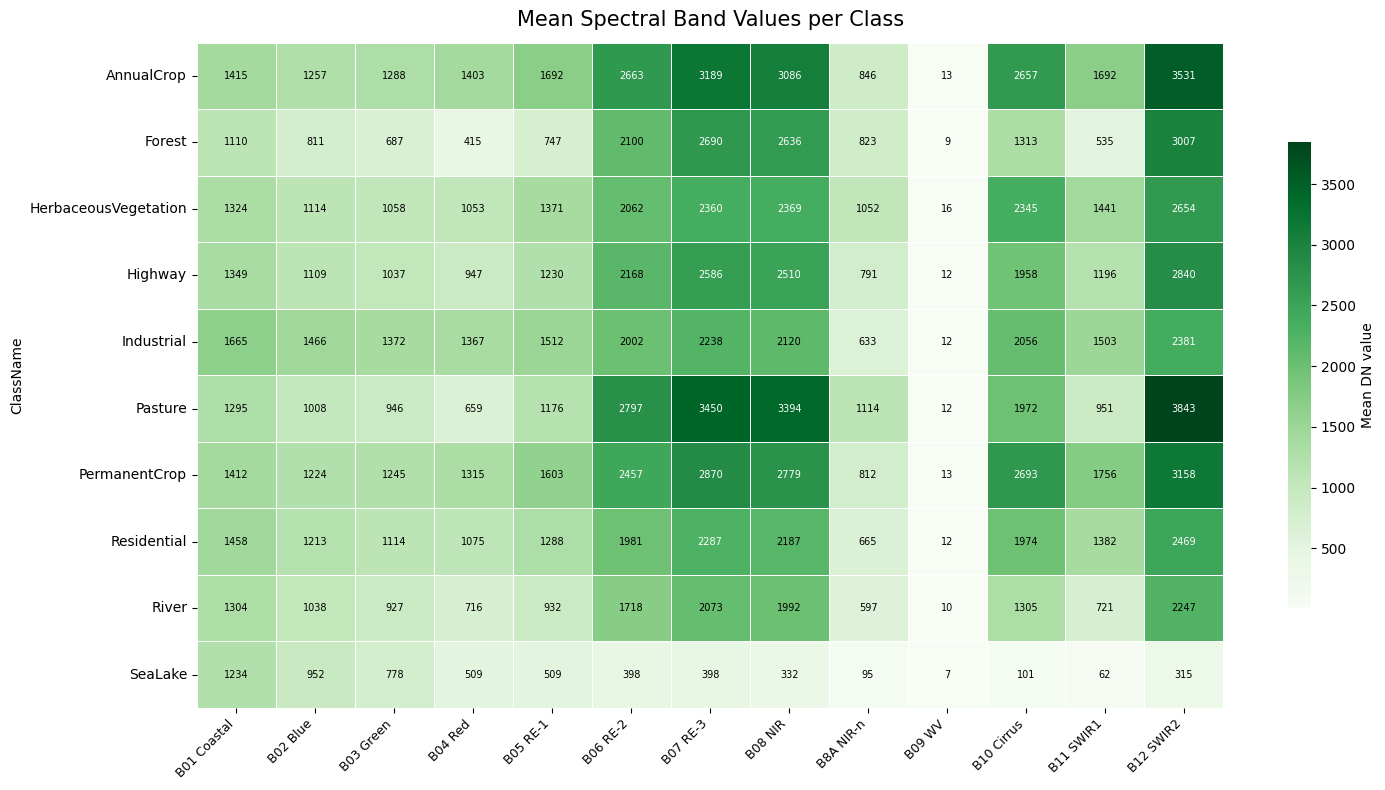

In [ ]:
BAND_NAMES = [
    'B01 Coastal', 'B02 Blue', 'B03 Green', 'B04 Red',
    'B05 RE-1',    'B06 RE-2', 'B07 RE-3',  'B08 NIR',
    'B8A NIR-n',   'B09 WV',   'B10 Cirrus','B11 SWIR1', 'B12 SWIR2'
]

if ms_dataset is not None:
    rows = []
    for path, lbl in tqdm(ms_dataset.samples, desc='Computing band means'):
        with rasterio.open(path) as src:
            arr = src.read().astype(np.float32)   # (13, H, W)
        rows.append({'ClassName': ms_class_names[lbl],
                     **{BAND_NAMES[b]: float(arr[b].mean()) for b in range(arr.shape[0])}})

    band_df   = pd.DataFrame(rows)
    band_means = band_df.groupby('ClassName')[BAND_NAMES].mean().astype(int)

    plt.figure(figsize=(15, 8))
    ax = sns.heatmap(band_means, cmap='Greens', linewidths=0.4, linecolor='white',
                     cbar_kws={'label': 'Mean DN value', 'shrink': 0.7}, annot=False)

    cmap_obj = plt.get_cmap('Greens')
    norm_obj = plt.Normalize(band_means.values.min(), band_means.values.max())
    for ii in range(band_means.shape[0]):
        for jj in range(band_means.shape[1]):
            val   = band_means.values[ii, jj]
            c     = cmap_obj(norm_obj(val))
            lum   = 0.299*c[0] + 0.587*c[1] + 0.114*c[2]
            ax.text(jj+0.5, ii+0.5, str(val), ha='center', va='center',
                    fontsize=7, color='white' if lum < 0.55 else 'black')

    ax.set_xticklabels(BAND_NAMES, rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=10)
    plt.title('Mean Spectral Band Values per Class', fontsize=15, pad=12)
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'eda_band_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

### (E) Top Spectral Bands per Class (Ranking):

In [ ]:
if ms_dataset is not None:
    rank_cols    = [f'Rank {i}' for i in range(1, len(BAND_NAMES) + 1)]
    ranking_rows = [band_means.loc[cls].sort_values(ascending=False).index.tolist()
                    for cls in band_means.index]
    ranking_df   = pd.DataFrame(ranking_rows, index=band_means.index, columns=rank_cols)
    print('Top-5 bands per class:')
    display(ranking_df.iloc[:, :5])

Top-5 bands per class:


,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5
ClassName,,,,,
AnnualCrop,B12 SWIR2,B07 RE-3,B08 NIR,B06 RE-2,B10 Cirrus
Forest,B12 SWIR2,B07 RE-3,B08 NIR,B06 RE-2,B10 Cirrus
HerbaceousVegetation,B12 SWIR2,B08 NIR,B07 RE-3,B10 Cirrus,B06 RE-2
Highway,B12 SWIR2,B07 RE-3,B08 NIR,B06 RE-2,B10 Cirrus
Industrial,B12 SWIR2,B07 RE-3,B08 NIR,B10 Cirrus,B06 RE-2
Pasture,B12 SWIR2,B07 RE-3,B08 NIR,B06 RE-2,B10 Cirrus
PermanentCrop,B12 SWIR2,B07 RE-3,B08 NIR,B10 Cirrus,B06 RE-2
Residential,B12 SWIR2,B07 RE-3,B08 NIR,B06 RE-2,B10 Cirrus
River,B12 SWIR2,B07 RE-3,B08 NIR,B06 RE-2,B10 Cirrus


## **(3) Data Preprocessing & Augmentation for RGB and JPEG Data:**
For RGB and JPEG data, a similar preprocessing and augmentation pipeline is applied, focusing on preparing the images for deep learning models:

*   **Normalization**: Image pixel values are scaled to a range of [0, 1]. This is a crucial step to ensure consistent input ranges for neural networks, aiding in faster convergence and better performance.
*   **Augmentation**: To enhance the model's robustness and generalization, various augmentation techniques are employed. These include:
    *   **Rotation**: Random rotations are applied to the images.
    *   **Flipping**: Images are randomly flipped horizontally and vertically.
    *   **Zooming**: Random zoom operations are performed.
    *   **Shearing**: Shear transformations are applied.
    These augmentations simulate diverse real-world conditions, preventing the model from overfitting to specific orientations or scales in the training data.
*   **Generator Configuration**: Data generators are configured for efficient loading of RGB and JPEG images in batches. This approach is memory-efficient, especially beneficial when working with large datasets, as it loads data on-the-fly during training rather than pre-loading the entire dataset into memory.

### (A) Compute Actual Normalisation Statistics (RGB Dataset):

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute per-channel mean & std over the TRAINING split only (no data leakage).
# We use a simple transform (ToTensor) without normalisation for this pass.
# ─────────────────────────────────────────────────────────────────────────────
unnorm_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor()
])

# Temporarily replace the transform for the statistics pass
rgb_dataset.transform = unnorm_transform
stats_loader = DataLoader(Subset(rgb_dataset, train_idx),
                          batch_size=256, shuffle=False, num_workers=2)

mean_acc = torch.zeros(3)
std_acc  = torch.zeros(3)
n_batches = 0

for imgs, _ in tqdm(stats_loader, desc='Computing RGB statistics'):
    # imgs: (B, C, H, W)
    mean_acc += imgs.mean(dim=[0, 2, 3])
    std_acc  += imgs.std (dim=[0, 2, 3])
    n_batches += 1

RGB_MEAN = (mean_acc / n_batches).tolist()
RGB_STD  = (std_acc  / n_batches).tolist()

print(f'RGB mean (R, G, B): {[round(v,4) for v in RGB_MEAN]}')
print(f'RGB std  (R, G, B): {[round(v,4) for v in RGB_STD]}')

# Restore the full transform with actual statistics
rgb_dataset.transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=RGB_MEAN, std=RGB_STD)
])

Computing RGB statistics:   0%|          | 0/85 [00:00<?, ?it/s]

RGB mean (R, G, B): [0.3441, 0.3801, 0.4076]
RGB std  (R, G, B): [0.2021, 0.1365, 0.1152]


### (B) Compute Normalisation Statistics (Multispectral Dataset):

In [ ]:
if ms_dataset is not None:
    #Temporarily use raw loader (no normalisation)
    ms_dataset.transform = transforms.Compose([
        transforms.Resize((64, 64), antialias=True),
        transforms.CenterCrop(64),
    ])

    ms_stats_loader = DataLoader(Subset(ms_dataset, ms_train_idx),
                                 batch_size=64, shuffle=False, num_workers=2)

    N_BANDS   = 13
    ms_mean   = torch.zeros(N_BANDS)
    ms_std    = torch.zeros(N_BANDS)
    ms_nbatch = 0

    for imgs, _ in tqdm(ms_stats_loader, desc='Computing MS statistics'):
        # imgs: (B, 13, H, W)
        ms_mean += imgs.mean(dim=[0, 2, 3])
        ms_std  += imgs.std (dim=[0, 2, 3])
        ms_nbatch += 1

    MS_MEAN = (ms_mean / ms_nbatch).tolist()
    MS_STD  = (ms_std  / ms_nbatch).tolist()

    print('MS per-band statistics (computed from training split):')
    for b, (m, s) in enumerate(zip(MS_MEAN, MS_STD)):
        print(f'  {BAND_NAMES[b]:<18}  mean={m:8.2f}   std={s:8.2f}')

    # Restore MS dataset transform with actual per-band normalisation
    ms_dataset.transform = transforms.Compose([
        transforms.Resize((64, 64), antialias=True),
        transforms.CenterCrop(64),
        transforms.Normalize(mean=MS_MEAN, std=MS_STD)
    ])
    print('\n MS dataset transform updated with computed per-band statistics.')

Computing MS statistics:   0%|          | 0/338 [00:00<?, ?it/s]

MS per-band statistics (computed from training split):
  B01 Coastal         mean= 1353.48   std=  241.68
  B02 Blue            mean= 1116.89   std=  329.60
  B03 Green           mean= 1041.34   std=  391.10
  B04 Red             mean=  945.85   std=  588.77
  B05 RE-1            mean= 1198.16   std=  561.34
  B06 RE-2            mean= 2001.29   std=  852.64
  B07 RE-3            mean= 2372.07   std= 1076.47
  B08 NIR             mean= 2299.16   std= 1108.48
  B8A NIR-n           mean=  730.52   std=  398.09
  B09 WV              mean=   12.10   std=    4.52
  B10 Cirrus          mean= 1820.51   std=  994.75
  B11 SWIR1           mean= 1117.43   std=  754.05
  B12 SWIR2           mean= 2597.99   std= 1219.94

 MS dataset transform updated with computed per-band statistics.


### (C) Define Augmentation Pipelines:

###Two separate pipelines: one for RGB (PIL-based), one for TIFF/MS tensors.

In [ ]:
#  RGB  —  PIL-based augmentations  →  tensor  →  normalise

rgb_train_transform = transforms.Compose([
    transforms.Resize(72),
    transforms.RandomCrop(64),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=RGB_MEAN, std=RGB_STD)
])

rgb_val_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=RGB_MEAN, std=RGB_STD)
])

# ─────────────────────────────────────────────────────────────────────────────
#  MS / TIFF  —  tensor-based augmentations  →  normalise
#  Note: ColorJitter and many PIL ops are NOT applicable to 13-band tensors.
#        Safe ops: geometric flips / rotations on tensors.
# ─────────────────────────────────────────────────────────────────────────────
if ms_dataset is not None:
    ms_train_transform = transforms.Compose([
        transforms.Resize((72, 72), antialias=True),
        transforms.RandomCrop(64),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.Normalize(mean=MS_MEAN, std=MS_STD)
    ])

    ms_val_transform = transforms.Compose([
        transforms.Resize((64, 64), antialias=True),
        transforms.CenterCrop(64),
        transforms.Normalize(mean=MS_MEAN, std=MS_STD)
    ])

print('Augmentation transforms defined for both RGB and MS pipelines.')

Augmentation transforms defined for both RGB and MS pipelines.


### (D) Apply Augmentation Transforms & Rebuild DataLoaders:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# For Subset objects, we cannot assign transforms directly.  Instead we create
# thin wrapper datasets that override the transform per split.
# ─────────────────────────────────────────────────────────────────────────────
class TransformSubset(Dataset):
    """Wrap a Subset and apply a per-split transform."""
    def __init__(self, subset: Subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        # Load raw sample from underlying dataset without the dataset-level transform
        sample_idx = self.subset.indices[idx]
        path, label = self.subset.dataset.samples[sample_idx]
        img = self.subset.dataset.loader(path)   # PIL Image (RGB) or tensor (MS)
        if self.transform:
            img = self.transform(img)
        return img, label


# RGB DataLoaders
train_set_rgb = TransformSubset(train_data, rgb_train_transform)
val_set_rgb   = TransformSubset(val_data,   rgb_val_transform)
test_set_rgb  = TransformSubset(test_data,  rgb_val_transform)

train_loader = DataLoader(train_set_rgb, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set_rgb,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set_rgb,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('RGB DataLoaders ready.')
imgs, lbls = next(iter(train_loader))
print(f'  Batch shape: {imgs.shape}  labels: {lbls.shape}')

# MS DataLoaders
if ms_dataset is not None:
    train_set_ms = TransformSubset(ms_train_data, ms_train_transform)
    val_set_ms   = TransformSubset(ms_val_data,   ms_val_transform)
    test_set_ms  = TransformSubset(ms_test_data,  ms_val_transform)

    ms_train_loader = DataLoader(train_set_ms, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    ms_val_loader   = DataLoader(val_set_ms,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    ms_test_loader  = DataLoader(test_set_ms,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print('\nMS DataLoaders ready.')
    ms_imgs, ms_lbls = next(iter(ms_train_loader))
    print(f'  Batch shape: {ms_imgs.shape}  labels: {ms_lbls.shape}')

RGB DataLoaders ready.
  Batch shape: torch.Size([32, 3, 64, 64])  labels: torch.Size([32])

MS DataLoaders ready.
  Batch shape: torch.Size([32, 13, 64, 64])  labels: torch.Size([32])


### (E) Visualise Augmentation Examples:

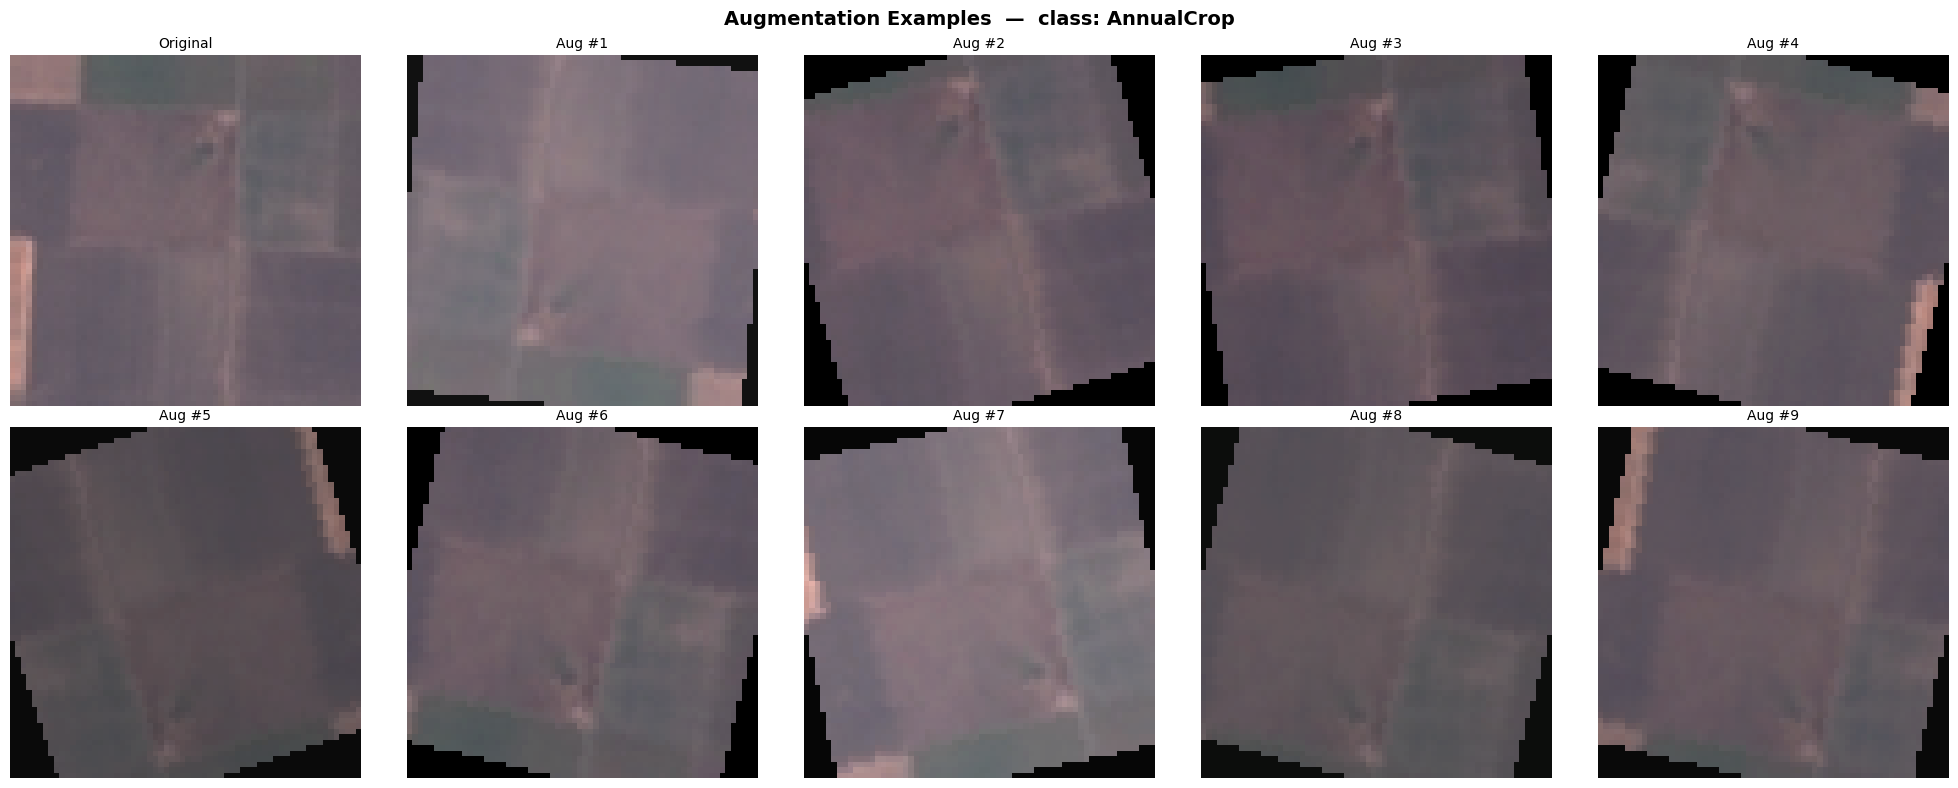

In [ ]:
def denorm(tensor, mean, std):
    """Reverse normalisation for display purposes."""
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.permute(1, 2, 0).numpy().clip(0, 1)

# Pick one image and show 8 augmented versions
raw_path, raw_lbl = rgb_dataset.samples[0]
from PIL import Image
raw_pil = Image.open(raw_path).convert('RGB')

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle(f'Augmentation Examples  —  class: {class_names[raw_lbl]}',
             fontsize=14, fontweight='bold')

# Original (no augmentation)
orig = rgb_val_transform(raw_pil)
axes[0, 0].imshow(denorm(orig, RGB_MEAN, RGB_STD))
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')

# 9 augmented versions
for idx in range(1, 10):
    r, c  = divmod(idx, 5)
    aug   = rgb_train_transform(raw_pil)
    axes[r, c].imshow(denorm(aug, RGB_MEAN, RGB_STD))
    axes[r, c].set_title(f'Aug #{idx}', fontsize=10)
    axes[r, c].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'augmentation_examples.png'), dpi=150, bbox_inches='tight')
plt.show()

# Model Training

Using device: cpu

✅ RGB MODEL READY
✅ MS MODEL READY

TRAINING RGB MODEL


  0%|          | 0/675 [00:00<?, ?it/s]


Epoch 1/10
Train Loss: 0.9456
Train Accuracy: 69.27%
Validation Loss: 0.6830
Validation Accuracy: 77.52%


  0%|          | 0/675 [00:00<?, ?it/s]


Epoch 2/10
Train Loss: 0.7634
Train Accuracy: 74.72%
Validation Loss: 0.6214
Validation Accuracy: 80.37%


...


Epoch 8/10
Train Loss: 0.6316
Train Accuracy: 80.95%
Validation Loss: 0.2757
Validation Accuracy: 91.67%


  0%|          | 0/675 [00:00<?, ?it/s]


Epoch 9/10
Train Loss: 0.5945
Train Accuracy: 81.86%
Validation Loss: 0.2450
Validation Accuracy: 92.07%


  0%|          | 0/675 [00:00<?, ?it/s]


Epoch 10/10
Train Loss: 0.5485
Train Accuracy: 83.22%
Validation Loss: 0.2301
Validation Accuracy: 93.63%

✅ RGB Model saved to: /content/drive/MyDrive/DEPIProject/resnet50_rgb.pth
✅ MS Model saved to: /content/drive/MyDrive/DEPIProject/resnet50_ms.pth


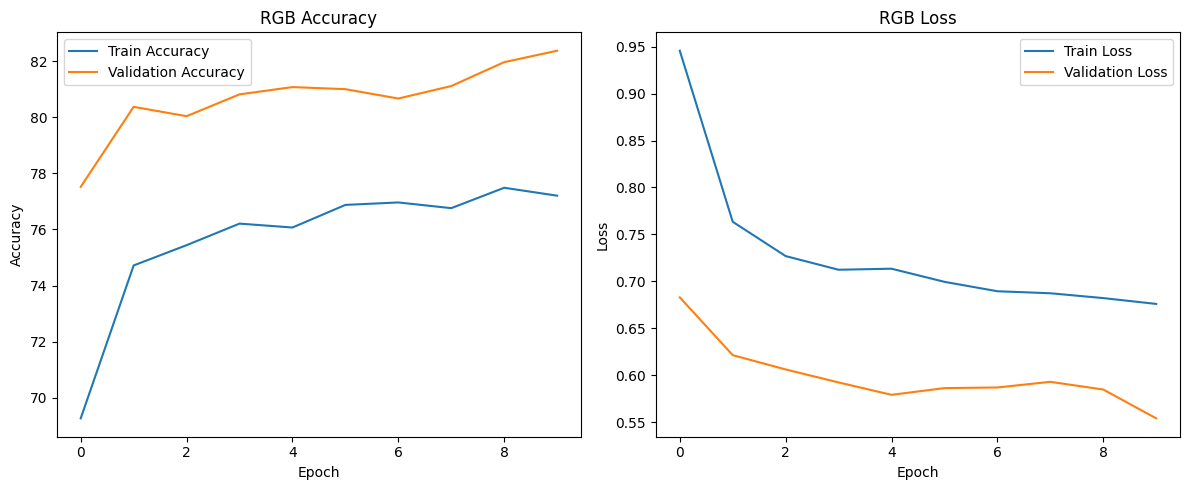

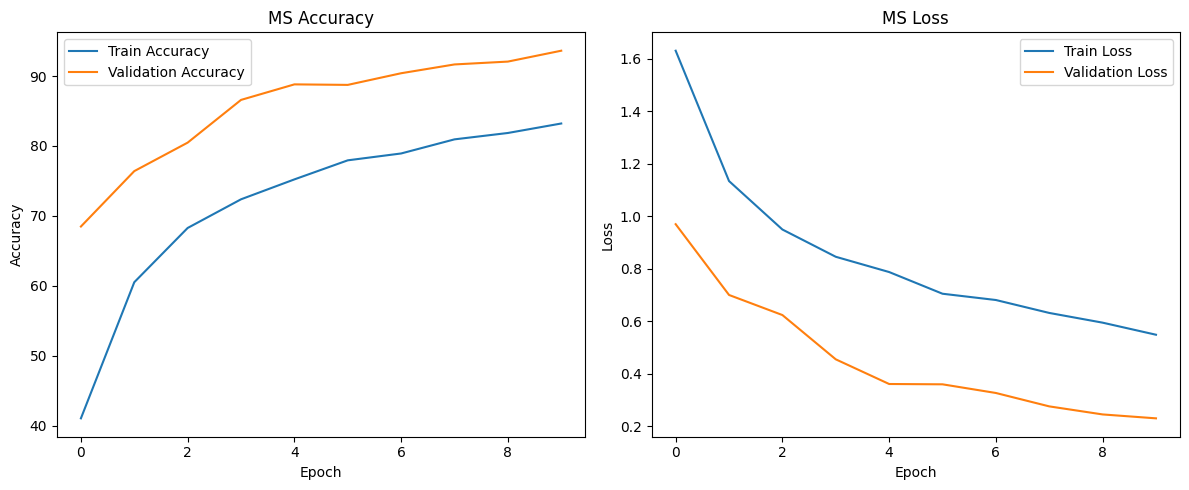


RGB TEST RESULTS

✅ Test Accuracy: 82.26%

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.85      0.82      0.83       300
              Forest       0.84      0.89      0.87       300
HerbaceousVegetation       0.83      0.79      0.81       300
             Highway       0.69      0.85      0.76       250
          Industrial       0.89      0.88      0.88       250
             Pasture       0.77      0.77      0.77       200
       PermanentCrop       0.79      0.70      0.74       250
         Residential       0.83      0.91      0.87       300
               River       0.79      0.80      0.80       250
             SeaLake       0.98      0.79      0.87       300

            accuracy                           0.82      2700
           macro avg       0.82      0.82      0.82      2700
        weighted avg       0.83      0.82      0.82      2700



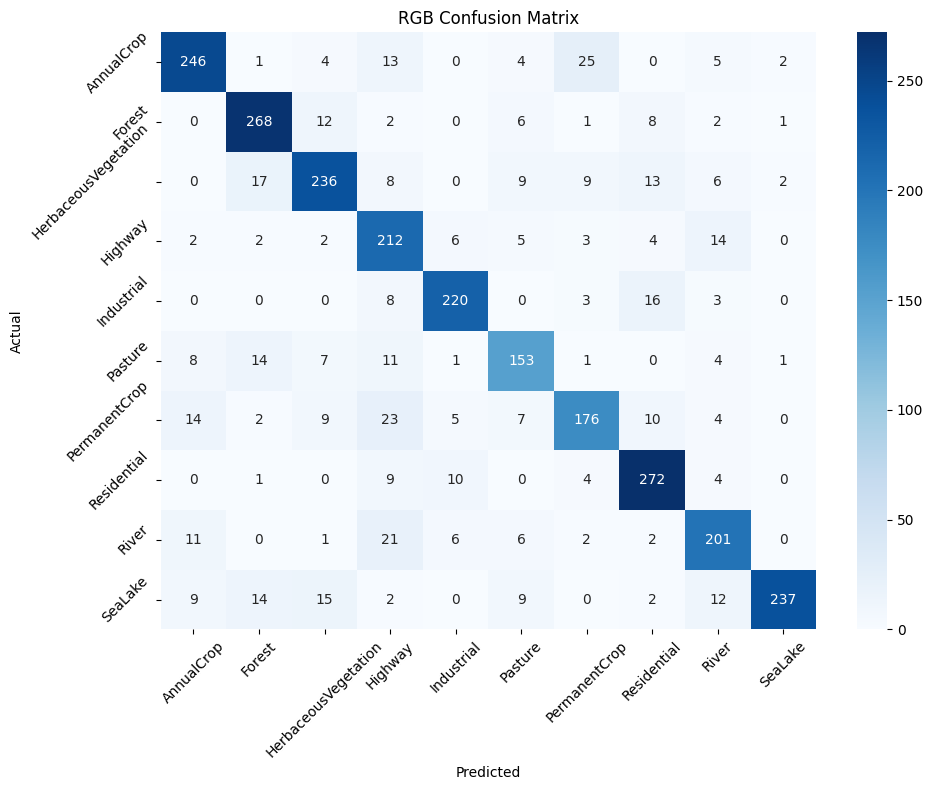


MS TEST RESULTS

✅ Test Accuracy: 92.56%

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.88      0.94      0.91       300
              Forest       0.94      0.99      0.96       300
HerbaceousVegetation       0.89      0.90      0.90       300
             Highway       0.93      0.77      0.84       250
          Industrial       0.87      0.97      0.92       250
             Pasture       0.92      0.93      0.92       200
       PermanentCrop       0.94      0.82      0.88       250
         Residential       0.94      0.94      0.94       300
               River       0.95      0.98      0.97       250
             SeaLake       0.99      1.00      0.99       300

            accuracy                           0.93      2700
           macro avg       0.93      0.92      0.92      2700
        weighted avg       0.93      0.93      0.92      2700



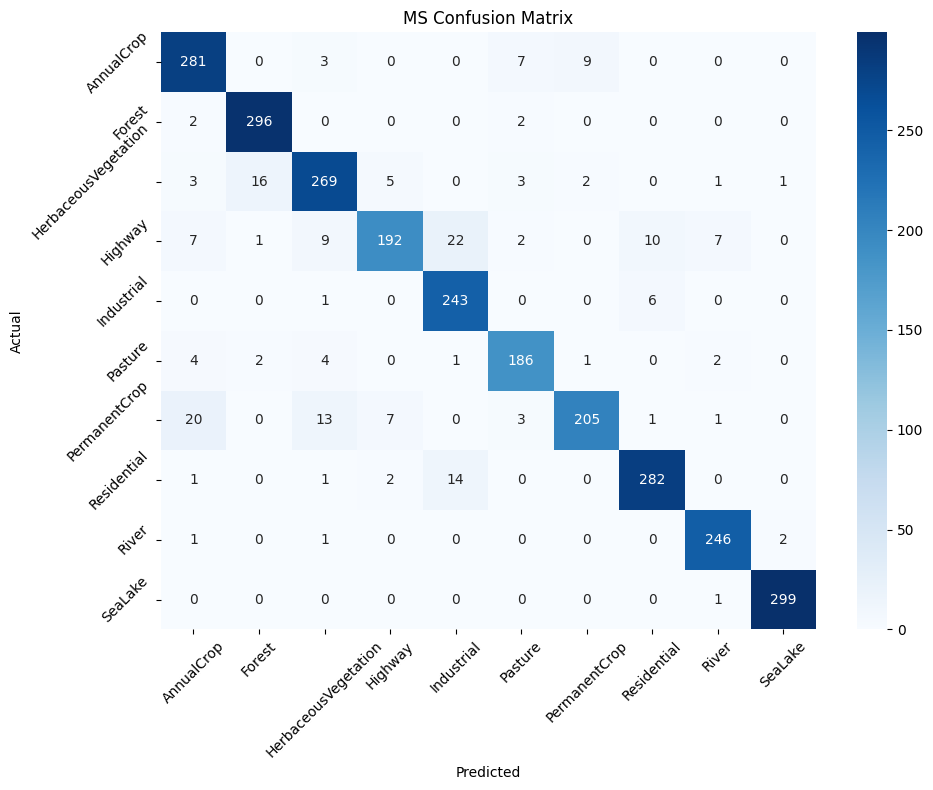

In [ ]:
from torch import nn, optim
from torchvision import models
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

rgb_model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

for param in rgb_model.parameters():
    param.requires_grad = False

num_features_rgb = rgb_model.fc.in_features

rgb_model.fc = nn.Sequential(
    nn.Linear(num_features_rgb, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(class_names))
)

rgb_model = rgb_model.to(device)

print("\n✅ RGB MODEL READY")

ms_model = models.resnet50(weights=None)

# Change first conv layer from 3 channels -> 13 channels
ms_model.conv1 = nn.Conv2d(
    13,
    64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

for name, param in ms_model.named_parameters():

    if "conv1" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_features_ms = ms_model.fc.in_features

ms_model.fc = nn.Sequential(
    nn.Linear(num_features_ms, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(ms_class_names))
)

ms_model = ms_model.to(device)

print("✅ MS MODEL READY")

criterion_rgb = nn.CrossEntropyLoss()
criterion_ms = nn.CrossEntropyLoss()

optimizer_rgb = optim.Adam(
    rgb_model.fc.parameters(),
    lr=0.001
)

optimizer_ms = optim.Adam(
    filter(lambda p: p.requires_grad, ms_model.parameters()),
    lr=0.001
)

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10
):

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader, leave=True)

        for images, labels in loop:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        model.eval()

        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Accuracy: {train_acc:.2f}%")
        print(f"Validation Loss: {val_loss:.4f}")
        print(f"Validation Accuracy: {val_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs

EPOCHS = 10

print("\n==============================")
print("TRAINING RGB MODEL")
print("==============================")

rgb_train_losses, rgb_val_losses, rgb_train_accs, rgb_val_accs = train_model(
    rgb_model,
    train_loader,
    val_loader,
    criterion_rgb,
    optimizer_rgb,
    epochs=EPOCHS
)

print("\n==============================")
print("TRAINING MS MODEL")
print("==============================")

ms_train_losses, ms_val_losses, ms_train_accs, ms_val_accs = train_model(
    ms_model,
    ms_train_loader,
    ms_val_loader,
    criterion_ms,
    optimizer_ms,
    epochs=EPOCHS
)

BASE_PATH = '/content/drive/MyDrive/DEPIProject'

rgb_model_path = os.path.join(BASE_PATH, "resnet50_rgb.pth")
ms_model_path = os.path.join(BASE_PATH, "resnet50_ms.pth")

torch.save(rgb_model.state_dict(), rgb_model_path)
torch.save(ms_model.state_dict(), ms_model_path)

print(f"\n✅ RGB Model saved to: {rgb_model_path}")
print(f"✅ MS Model saved to: {ms_model_path}")

def plot_curves(train_accs, val_accs, train_losses, val_losses, title):

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)

    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(f"{title} Accuracy")

    plt.legend()

    # Loss
    plt.subplot(1,2,2)

    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(f"{title} Loss")

    plt.legend()

    plt.tight_layout()
    plt.show()

plot_curves(
    rgb_train_accs,
    rgb_val_accs,
    rgb_train_losses,
    rgb_val_losses,
    "RGB"
)

plot_curves(
    ms_train_accs,
    ms_val_accs,
    ms_train_losses,
    ms_val_losses,
    "MS"
)

def evaluate_model(
    model,
    test_loader,
    class_names,
    title
):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_accuracy = accuracy_score(all_labels, all_preds)

    print(f"\n==============================")
    print(f"{title} TEST RESULTS")
    print("==============================")

    print(f"\n✅ Test Accuracy: {test_accuracy*100:.2f}%")

    print("\nClassification Report:\n")

    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=class_names
        )
    )

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title(f"{title} Confusion Matrix")

    plt.xticks(rotation=45)
    plt.yticks(rotation=45)

    plt.tight_layout()
    plt.show()

evaluate_model(
    rgb_model,
    test_loader,
    class_names,
    "RGB"
)

evaluate_model(
    ms_model,
    ms_test_loader,
    ms_class_names,
    "MS"
)